# Setup e leitura das bases processadas

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Detecta automaticamente a raiz do projeto
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() in ["notebook", "notebooks"]:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
ANO_ANALISE = 2021

emissao_estado = pd.read_csv(
    PROCESSED_DIR / f"emissao_estado_{ANO_ANALISE}.csv"
)

emissao_per_capita = pd.read_csv(
    PROCESSED_DIR / f"emissao_per_capita_{ANO_ANALISE}.csv"
)

emissao_setor = pd.read_csv(
    PROCESSED_DIR / f"emissao_setor_{ANO_ANALISE}.csv"
)

emissao_anual = pd.read_csv(
    PROCESSED_DIR / "emissao_anual_brasil.csv"
)

# Objetivo do Projeto

Este projeto analisa as emissões brasileiras de gases de efeito estufa utilizando dados do SEEG e do IBGE.

Perguntas respondidas:

- Quais estados mais emitem?
- Quais estados possuem maior emissão per capita?
- Quais setores mais contribuem para as emissões?
- Como as emissões evoluíram ao longo do tempo?
- Quais são os principais insights observados?

## Fonte dos Dados

- SEEG (Sistema de Estimativas de Emissões e Remoções de Gases de Efeito Estufa)
- IBGE (População estimada dos municípios brasileiros)

# 1. Entendendo os datasets processados

Nesta etapa analisamos os datasets gerados durante o processo de preparação dos dados.

O objetivo é compreender sua estrutura antes de iniciar as análises exploratórias.

In [28]:
datasets = {
    "Emissão por Estado": emissao_estado,
    "Emissão Per Capita": emissao_per_capita,
    "Emissão por Setor": emissao_setor,
    "Emissão Anual Brasil": emissao_anual
}

for nome, df in datasets.items():
    print(f"\n{'='*60}")
    print(nome)
    print(f"{'='*60}")
    print(df.info())
    display(df.head())


Emissão por Estado
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Estado   27 non-null     object 
 1   Emissao  27 non-null     float64
dtypes: float64(1), object(1)
memory usage: 564.0+ bytes
None


,Estado,Emissao
0,PA,4.479274e+08
1,MT,2.693745e+08
2,MG,1.682337e+08
3,SP,1.567297e+08
4,AM,1.388454e+08



Emissão Per Capita
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Estado              27 non-null     object 
 1   Emissao             27 non-null     float64
 2   UF                  27 non-null     object 
 3   populacao           27 non-null     int64  
 4   emissao_per_capita  27 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ KB
None


,Estado,Emissao,UF,populacao,emissao_per_capita
0,RR,6.157727e+07,RR,634805,97.001873
1,RO,1.378898e+08,RO,1616379,85.307831
2,MT,2.693745e+08,MT,3784239,71.183268
3,PA,4.479274e+08,PA,8442962,53.053344
4,AC,4.399571e+07,AC,829780,53.020934



Emissão por Setor
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nível 1 - Setor  5 non-null      object 
 1   Emissao          5 non-null      float64
dtypes: float64(1), object(1)
memory usage: 212.0+ bytes
None


,Nível 1 - Setor,Emissao
0,Mudança de Uso da Terra e Floresta,1.188189e+09
1,Agropecuária,6.007592e+08
2,Energia,4.346073e+08
3,Processos Industriais,1.079485e+08
4,Resíduos,9.112153e+07



Emissão Anual Brasil
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      52 non-null     int64  
 1   Emissao  52 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 964.0 bytes
None


,Ano,Emissao
0,1970,3.422406e+08
1,1971,3.622887e+08
2,1972,3.827717e+08
3,1973,4.111755e+08
4,1974,4.338716e+08


# 2. Estados com maiores emissões

Antes de analisar indicadores mais sofisticados, é importante identificar quais estados apresentaram os maiores volumes absolutos de emissão em 2021.

In [29]:
top10_estados = (
    emissao_estado
    .sort_values("Emissao", ascending=False)
    .head(10)
)

top10_estados

,Estado,Emissao
0,PA,4.479274e+08
1,MT,2.693745e+08
2,MG,1.682337e+08
3,SP,1.567297e+08
4,AM,1.388454e+08
5,RO,1.378898e+08
6,MA,1.171535e+08
7,RS,1.077646e+08
8,GO,9.289627e+07
9,PR,8.628577e+07


In [30]:
def format_bilhoes(valor):
    return f"{valor/1e9:.2f} bi"

def format_milhoes(valor):
    return f"{valor/1e6:.0f} mi"

def format_percentual(valor):
    return f"{valor:.1f}%"

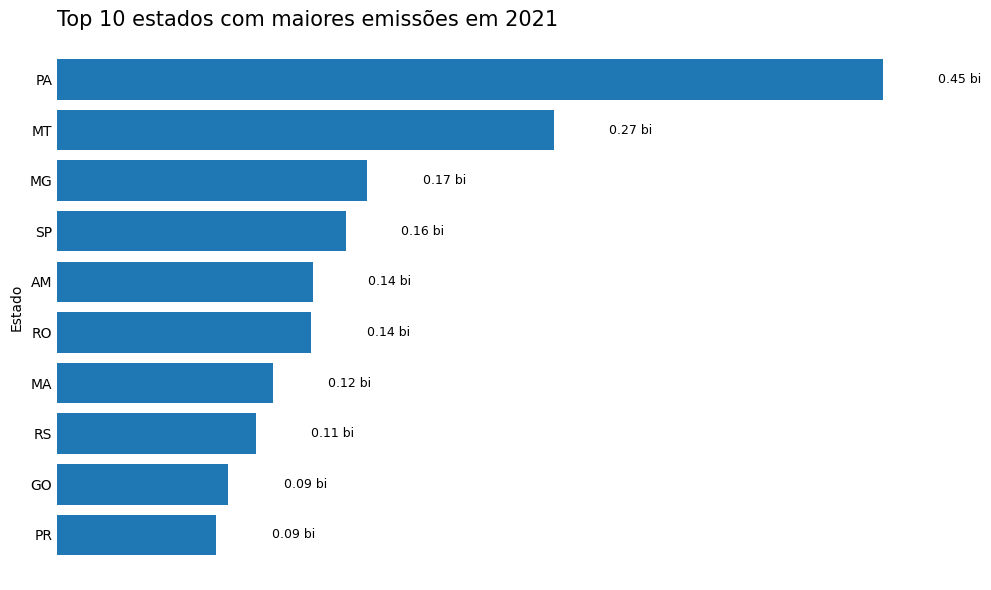

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_estados_plot = top10_estados.sort_values("Emissao", ascending=True)

bars = ax.barh(
    top10_estados_plot["Estado"],
    top10_estados_plot["Emissao"] / 1e9
)

ax.set_title(f"Top 10 estados com maiores emissões em {ANO_ANALISE}", fontsize = 15, loc='left')
ax.set_xlabel("Emissão total (bilhões tCO₂e)")
ax.set_ylabel("Estado")


for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f} bi",
        va="center",
        fontsize=9
    )

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which= 'both', length=0)

plt.tight_layout()
plt.show()

# 3. Emissões per capita

A análise absoluta favorece estados mais populosos.

Para avaliar o impacto relativo das emissões, utilizamos o indicador de emissão per capita.

In [32]:
top10_per_capita = (
    emissao_per_capita
    .sort_values("emissao_per_capita", ascending=False)
    .head(10)
)

top10_per_capita

,Estado,Emissao,UF,populacao,emissao_per_capita
0,RR,6.157727e+07,RR,634805,97.001873
1,RO,1.378898e+08,RO,1616379,85.307831
2,MT,2.693745e+08,MT,3784239,71.183268
3,PA,4.479274e+08,PA,8442962,53.053344
4,AC,4.399571e+07,AC,829780,53.020934
5,TO,5.664851e+07,TO,1584306,35.756044
6,AM,1.388454e+08,AM,3952262,35.130609
7,MS,8.149935e+07,MS,2833742,28.760330
8,MA,1.171535e+08,MA,6800605,17.226916
9,GO,9.289627e+07,GO,6950976,13.364493


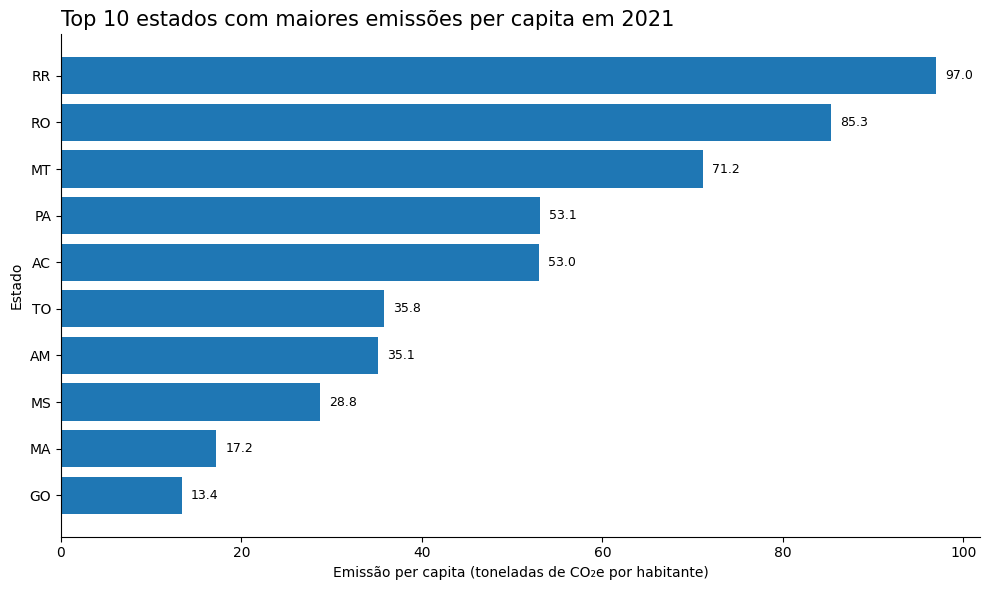

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_per_capita_plot = top10_per_capita.sort_values(
    "emissao_per_capita",
    ascending=True
)

bars = ax.barh(
    top10_per_capita_plot["Estado"],
    top10_per_capita_plot["emissao_per_capita"]
)

ax.set_title(f"Top 10 estados com maiores emissões per capita em {ANO_ANALISE}", fontsize = 15, loc='left')
ax.set_xlabel("Emissão per capita (toneladas de CO₂e por habitante)")
ax.set_ylabel("Estado")


for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        fontsize=9
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Emissão absoluta x emissão per capita

Nem sempre os estados que mais emitem em termos absolutos são aqueles com maior emissão por habitante.

Essa comparação permite identificar diferenças estruturais entre economia, população e perfil produtivo.

In [34]:
ranking_abs = emissao_estado.copy()
ranking_abs["rank_abs"] = ranking_abs["Emissao"].rank(
    ascending=False,
    method="dense"
)

ranking_pc = emissao_per_capita.copy()
ranking_pc["rank_pc"] = ranking_pc["emissao_per_capita"].rank(
    ascending=False,
    method="dense"
)

comparacao = ranking_abs.merge(
    ranking_pc[["Estado", "populacao", "emissao_per_capita", "rank_pc"]],
    on="Estado"
)

comparacao = comparacao.sort_values("rank_abs")

comparacao.head(10)

,Estado,Emissao,rank_abs,populacao,emissao_per_capita,rank_pc
0,PA,4.479274e+08,1.0,8442962,53.053344,4.0
1,MT,2.693745e+08,2.0,3784239,71.183268,3.0
2,MG,1.682337e+08,3.0,20732660,8.114427,13.0
3,SP,1.567297e+08,4.0,46024937,3.405322,21.0
4,AM,1.388454e+08,5.0,3952262,35.130609,7.0
5,RO,1.378898e+08,6.0,1616379,85.307831,2.0
6,MA,1.171535e+08,7.0,6800605,17.226916,9.0
7,RS,1.077646e+08,8.0,11088065,9.718976,11.0
8,GO,9.289627e+07,9.0,6950976,13.364493,10.0
9,PR,8.628577e+07,10.0,11835379,7.290495,15.0


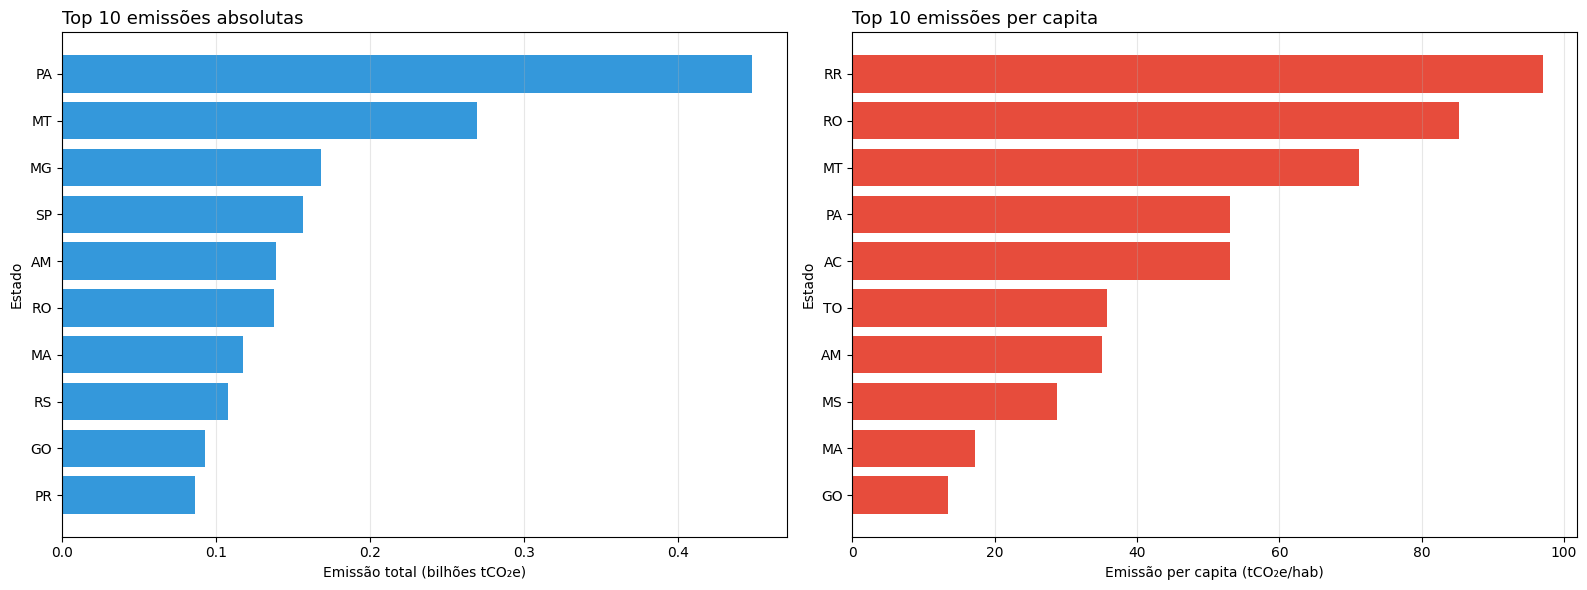

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_abs = emissao_estado.sort_values("Emissao", ascending=False).head(10)
top10_pc = emissao_per_capita.sort_values("emissao_per_capita", ascending=False).head(10)
top10_abs_plot = top10_abs.sort_values("Emissao", ascending=True)
top10_pc_plot = top10_pc.sort_values("emissao_per_capita", ascending=True)

bars_abs = axes[0].barh(
    top10_abs_plot["Estado"],
    top10_abs_plot["Emissao"] / 1e9,
    color="#3498db"
)

axes[0].set_title("Top 10 emissões absolutas", fontsize = 13, loc = 'left')
axes[0].set_xlabel("Emissão total (bilhões tCO₂e)")
axes[0].set_ylabel("Estado")
axes[0].grid(axis="x", alpha=0.3)


bars_pc = axes[1].barh(
    top10_pc_plot["Estado"],
    top10_pc_plot["emissao_per_capita"],
    color = "#e74c3c"
)

axes[1].set_title("Top 10 emissões per capita", fontsize = 13, loc = 'left')
axes[1].set_xlabel("Emissão per capita (tCO₂e/hab)")
axes[1].set_ylabel("Estado")
axes[1].grid(axis="x", alpha=0.3)



plt.tight_layout()
plt.show()

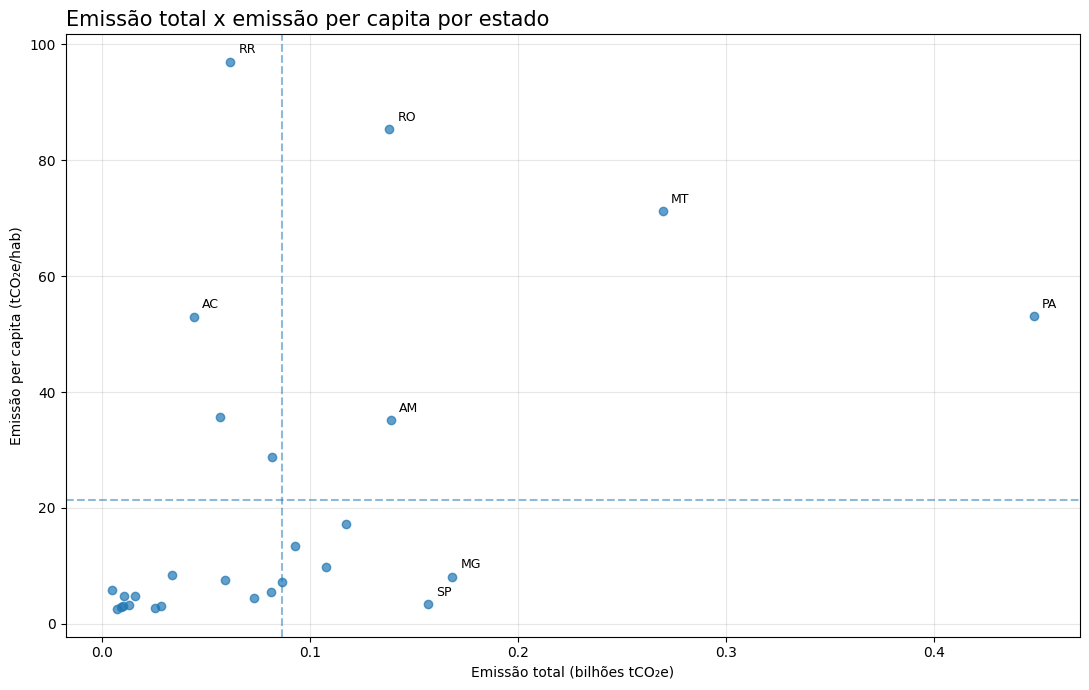

In [88]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    comparacao["Emissao"] / 1e9,
    comparacao["emissao_per_capita"],
    alpha=0.7
)

media_emissao = comparacao["Emissao"].mean() / 1e9
media_per_capita = comparacao["emissao_per_capita"].mean()

ax.axvline(media_emissao, linestyle="--", alpha=0.5)
ax.axhline(media_per_capita, linestyle="--", alpha=0.5)

estados_destaque = (
    set(comparacao.nlargest(5, "Emissao")["Estado"])
    | set(comparacao.nlargest(5, "emissao_per_capita")["Estado"])
)

for _, row in comparacao.iterrows():
    if row["Estado"] in estados_destaque:
        ax.annotate(
            row["Estado"],
            (row["Emissao"] / 1e9, row["emissao_per_capita"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

ax.set_title("Emissão total x emissão per capita por estado", fontsize = 15, loc='left')
ax.set_xlabel("Emissão total (bilhões tCO₂e)")
ax.set_ylabel("Emissão per capita (tCO₂e/hab)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A comparação entre emissões absolutas e emissões per capita revela diferenças importantes.

Estados com grandes populações tendem a aparecer entre os maiores emissores totais, mas não necessariamente lideram em emissão por habitante. Já estados menos populosos podem apresentar emissões per capita elevadas, indicando maior intensidade de emissões em relação ao tamanho da população.

Essa diferença reforça a importância de analisar os dois indicadores em conjunto.

# 5. Emissões por setor econômico

Após identificar os estados com maiores emissões absolutas e per capita, analisamos quais setores econômicos mais contribuem para as emissões brasileiras.

Essa análise ajuda a compreender quais atividades possuem maior impacto na composição das emissões nacionais.

In [37]:
emissao_setor.sort_values(
    "Emissao",
    ascending=False
)

,Nível 1 - Setor,Emissao
0,Mudança de Uso da Terra e Floresta,1.188189e+09
1,Agropecuária,6.007592e+08
2,Energia,4.346073e+08
3,Processos Industriais,1.079485e+08
4,Resíduos,9.112153e+07


In [39]:
setores_percentual = emissao_setor.copy()

total = setores_percentual["Emissao"].sum()

setores_percentual["Participacao (%)"] = (
    setores_percentual["Emissao"] / total * 100
)

setores_percentual.sort_values(
    "Participacao (%)",
    ascending=False
)

,Nível 1 - Setor,Emissao,Participacao (%)
0,Mudança de Uso da Terra e Floresta,1.188189e+09,49.045500
1,Agropecuária,6.007592e+08,24.797862
2,Energia,4.346073e+08,17.939518
3,Processos Industriais,1.079485e+08,4.455848
4,Resíduos,9.112153e+07,3.761272


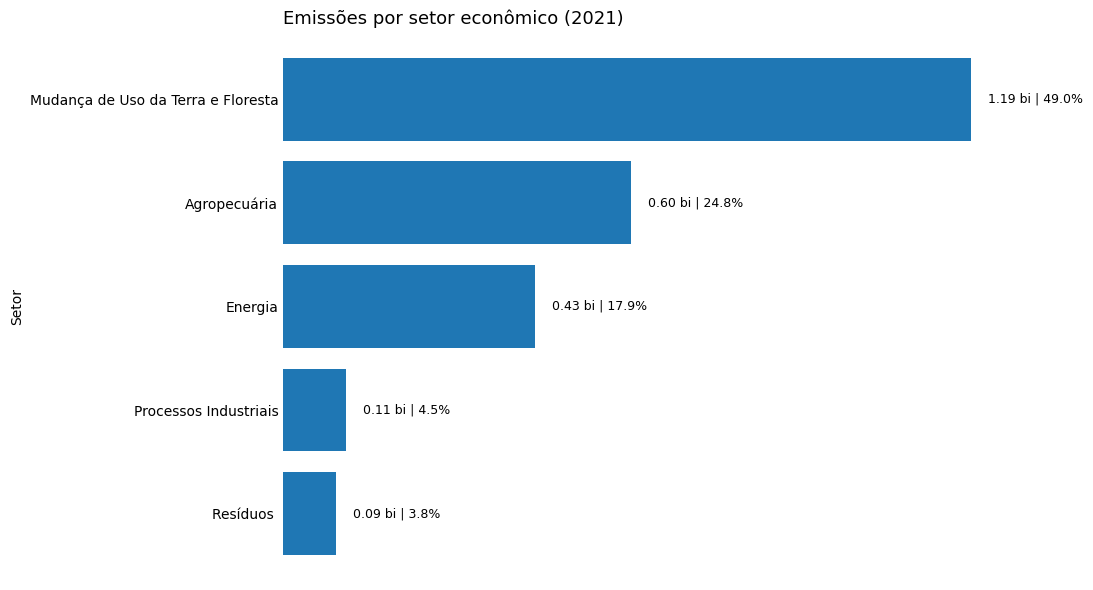

In [76]:
setores_percentual = emissao_setor.copy()

total_emissoes_setores = setores_percentual["Emissao"].sum()

setores_percentual["Participacao (%)"] = (
    setores_percentual["Emissao"] / total_emissoes_setores * 100
)

setores_plot = setores_percentual.sort_values("Emissao", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    setores_plot["Nível 1 - Setor"],
    setores_plot["Emissao"] / 1e9
)

ax.set_title(f"Emissões por setor econômico ({ANO_ANALISE})", fontsize = 13, loc = 'left')
ax.set_xlabel("Emissão (bilhões tCO₂e)")
ax.set_ylabel("Setor")


for bar, percentual in zip(bars, setores_plot["Participacao (%)"]):
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f} bi | {percentual:.1f}%",
        va="center",
        fontsize=9
    )

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which= 'both', length=0)

plt.tight_layout()
plt.show()

In [77]:
top3_setores = setores_percentual.sort_values(
    "Emissao",
    ascending=False
).head(3)

participacao_top3 = top3_setores["Participacao (%)"].sum()

print(
    f"Os 3 setores mais emissores concentram "
    f"{participacao_top3:.1f}% das emissões brasileiras em {ANO_ANALISE}."
)

Os 3 setores mais emissores concentram 91.8% das emissões brasileiras em 2021.


## Principais conclusões

A distribuição das emissões não ocorre de forma homogênea entre os setores econômicos.

Observa-se que poucos setores concentram grande parte das emissões nacionais, enquanto outros possuem participação significativamente menor.

Essa concentração sugere que políticas públicas e estratégias de mitigação direcionadas aos setores mais intensivos podem produzir impactos relevantes na redução das emissões.

# 6. Evolução das emissões brasileiras ao longo do tempo

Até aqui analisamos a distribuição das emissões em 2021.

Nesta etapa observamos a evolução histórica das emissões brasileiras entre 1970 e 2021, buscando identificar tendências, períodos de crescimento e possíveis mudanças estruturais ao longo do tempo.

In [40]:
emissao_anual.head()

,Ano,Emissao
0,1970,3.422406e+08
1,1971,3.622887e+08
2,1972,3.827717e+08
3,1973,4.111755e+08
4,1974,4.338716e+08


In [41]:
emissao_anual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      52 non-null     int64  
 1   Emissao  52 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 964.0 bytes


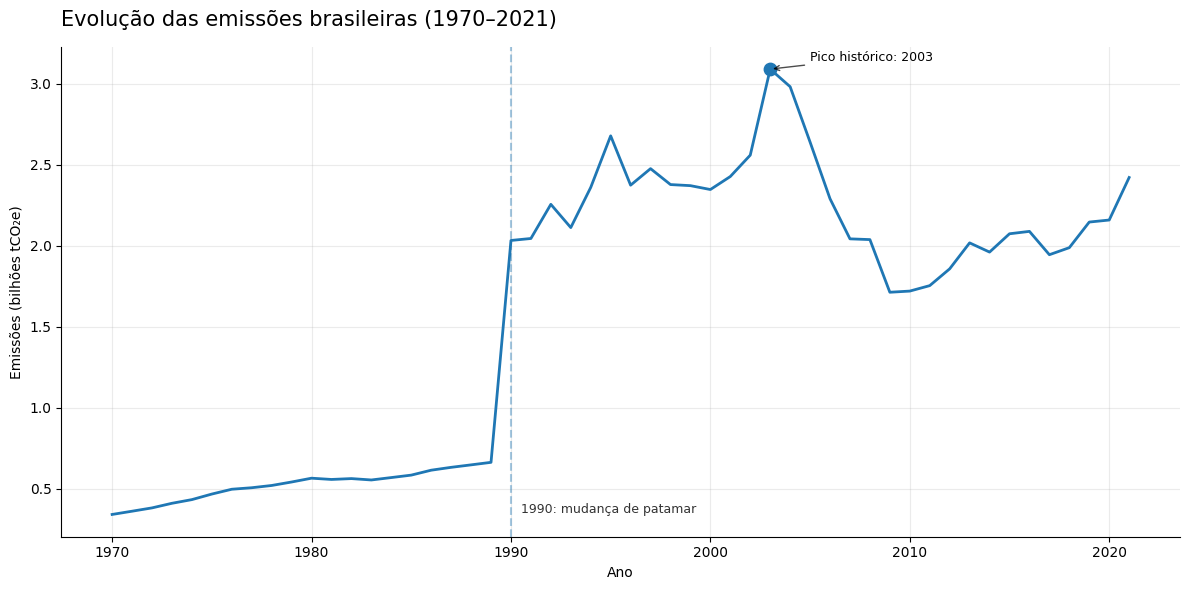

In [84]:
ano_pico = emissao_anual.loc[
    emissao_anual["Emissao"].idxmax()
]

ano_pico_valor = int(ano_pico["Ano"])
emissao_pico = ano_pico["Emissao"] / 1e9

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    emissao_anual["Ano"],
    emissao_anual["Emissao"] / 1e9,
    linewidth=2
)

ax.axvline(
    1990,
    linestyle="--",
    alpha=0.4
)

ax.text(
    1990 + 0.5,
    0.35,
    "1990: mudança de patamar",
    fontsize=9,
    alpha=0.8
)

ax.scatter(
    ano_pico_valor,
    emissao_pico,
    s=80
)

ax.annotate(
    f"Pico histórico: {ano_pico_valor}",
    xy=(ano_pico_valor, emissao_pico),
    xytext=(ano_pico_valor + 2, emissao_pico + 0.05),
    arrowprops=dict(arrowstyle="->", alpha=0.7),
    fontsize=9
)

ax.set_title("Evolução das emissões brasileiras (1970–2021)", pad=15, loc = 'left', fontsize = 15)
ax.set_xlabel("Ano")
ax.set_ylabel("Emissões (bilhões tCO₂e)")
ax.grid(True, alpha=0.25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
primeiro_ano = emissao_anual.iloc[0]["Emissao"]
ultimo_ano = emissao_anual.iloc[-1]["Emissao"]

crescimento = (
    (ultimo_ano - primeiro_ano)
    / primeiro_ano
) * 100

print(
    f"Crescimento acumulado entre 1970 e 2021: {crescimento:.2f}%"
)

Crescimento acumulado entre 1970 e 2021: 607.87%


In [44]:
emissao_anual["Variacao (%)"] = (
    emissao_anual["Emissao"]
    .pct_change()
    * 100
)

emissao_anual.head()

,Ano,Emissao,Variacao (%)
0,1970,3.422406e+08,NaN
1,1971,3.622887e+08,5.857896
2,1972,3.827717e+08,5.653794
3,1973,4.111755e+08,7.420551
4,1974,4.338716e+08,5.519810


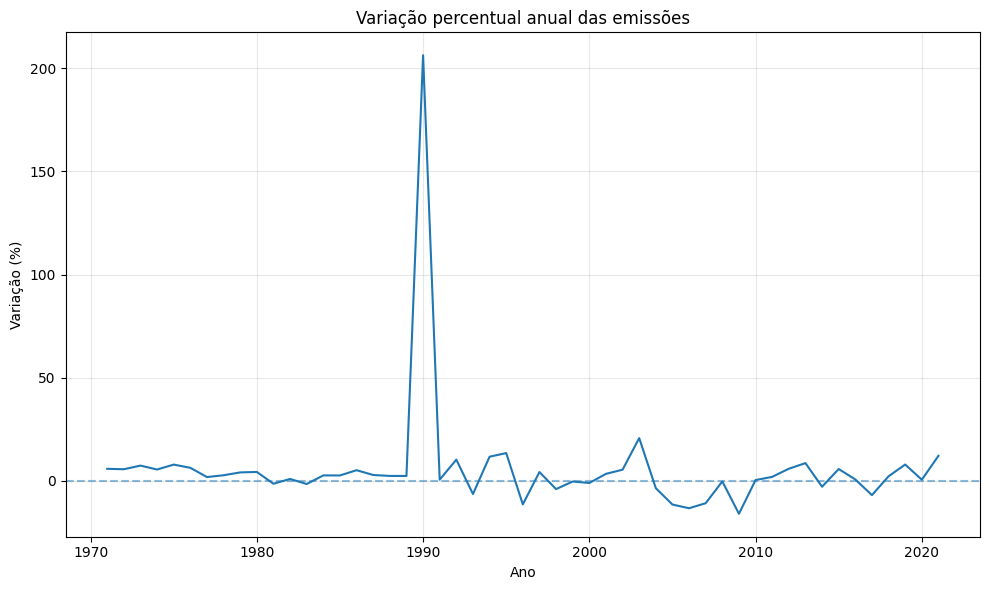

In [45]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    emissao_anual["Ano"],
    emissao_anual["Variacao (%)"]
)

ax.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

ax.set_title(
    "Variação percentual anual das emissões"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Variação (%)")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
ano_pico = emissao_anual.loc[
    emissao_anual["Emissao"].idxmax()
]

print(
    f"""
Ano de maior emissão: {int(ano_pico['Ano'])}

Emissão:
{ano_pico['Emissao']/1e9:.2f} bilhões tCO₂e

Variação em relação ao ano anterior:
{ano_pico['Variacao (%)']:.2f}%
"""
)


Ano de maior emissão: 2003

Emissão:
3.09 bilhões tCO₂e

Variação em relação ao ano anterior:
20.75%



In [48]:
maior_aumento = emissao_anual.loc[
    emissao_anual["Variacao (%)"].idxmax()
]

maior_queda = emissao_anual.loc[
    emissao_anual["Variacao (%)"].idxmin()
]

print(
    f"Maior aumento: {int(maior_aumento['Ano'])} "
    f"({maior_aumento['Variacao (%)']:.2f}%)"
)

print(
    f"Maior queda: {int(maior_queda['Ano'])} "
    f"({maior_queda['Variacao (%)']:.2f}%)"
)

Maior aumento: 1990 (206.32%)
Maior queda: 2009 (-15.94%)


### Investigação do salto observado em 1990

Durante a análise da série histórica foi identificado um crescimento atípico entre 1989 e 1990.

Para compreender melhor esse comportamento, foram analisados os valores absolutos dos anos imediatamente anteriores e posteriores.

In [49]:
emissao_anual[
    emissao_anual["Ano"].between(1987, 1992)
]

,Ano,Emissao,Variacao (%)
17,1987,6.331608e+08,2.869077
18,1988,6.484419e+08,2.413459
19,1989,6.640016e+08,2.399555
20,1990,2.033944e+09,206.316084
21,1991,2.046070e+09,0.596188
22,1992,2.256950e+09,10.306590


Ao analisar os valores absolutos dos anos subsequentes, observa-se que as emissões permanecem em um novo patamar, sugerindo uma mudança estrutural na série histórica e não apenas uma oscilação pontual.

Uma investigação mais aprofundada da metodologia utilizada pelo SEEG seria necessária para determinar a origem exata desse comportamento.

## Principais marcos da série histórica

A análise da evolução das emissões brasileiras permitiu identificar quatro períodos distintos:

- Crescimento gradual entre 1970 e 1989.
- Mudança estrutural observada em 1990.
- Pico histórico registrado em 2003.
- Redução relevante entre 2004 e 2009, seguida de recuperação gradual até 2021.

# 7. Principais Insights

A análise exploratória permitiu identificar padrões relevantes sobre a distribuição e evolução das emissões brasileiras de gases de efeito estufa.

Os principais achados estão resumidos abaixo.

### - Emissão absoluta não representa necessariamente maior impacto por habitante

Estados com grandes populações aparecem entre os maiores emissores absolutos, porém nem sempre lideram o ranking de emissões per capita.

A comparação dos dois indicadores mostrou que estados menos populosos podem apresentar intensidade de emissões significativamente maior quando o fator populacional é considerado.

### - As emissões estão concentradas em poucos setores

A análise setorial revelou uma concentração relevante das emissões em um grupo reduzido de atividades econômicas.

Esse resultado sugere que ações direcionadas aos setores mais intensivos podem gerar impactos significativos na redução das emissões nacionais.

### - Mudança estrutural observada em 1990

A série histórica apresentou um crescimento superior a 200% entre 1989 e 1990.

Como os anos seguintes permaneceram em um patamar elevado, o comportamento observado não parece representar uma oscilação pontual, indicando uma possível mudança estrutural na série de dados.

### - Pico histórico registrado em 2003

O maior volume de emissões da série foi observado em 2003, quando o Brasil atingiu aproximadamente 3,09 bilhões de toneladas de CO₂ equivalente.

Após esse período, observou-se uma redução significativa nas emissões até o final da década.

### - Tendência recente de recuperação das emissões

Após o período de queda observado entre 2004 e 2009, as emissões voltaram a crescer gradualmente.

Em 2021, os níveis observados permanecem abaixo do pico histórico, mas acima dos valores registrados no final da década de 2000.

# 8. Próximos Passos

Este projeto representa uma análise exploratória inicial da base de emissões do SEEG.

Possíveis evoluções futuras incluem:

- Construção de dashboards interativos em Power BI;
- Integração dos dados em banco SQL para consultas analíticas;
- Análise geoespacial das emissões por estado;
- Desenvolvimento de modelos preditivos para projeção de emissões futuras;
- Cruzamento com indicadores socioeconômicos e ambientais do IBGE;
- Construção de aplicações interativas utilizando Streamlit.